In [1]:
!pip install lightgbm

In [2]:
!pip install xgboost

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [4]:
# Each image is gray scale and 28*28 pixels
# Each image has a total of 784 pixels
# In the given csv file each row contains all the 784 pixels of the image and a label
data = pd.read_csv('MNIST digits.csv')
data.head(10)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [6]:
data.label.unique()

array([1, 0, 4, 7, 3, 5, 8, 9, 2, 6], dtype=int64)

<AxesSubplot:xlabel='label', ylabel='count'>

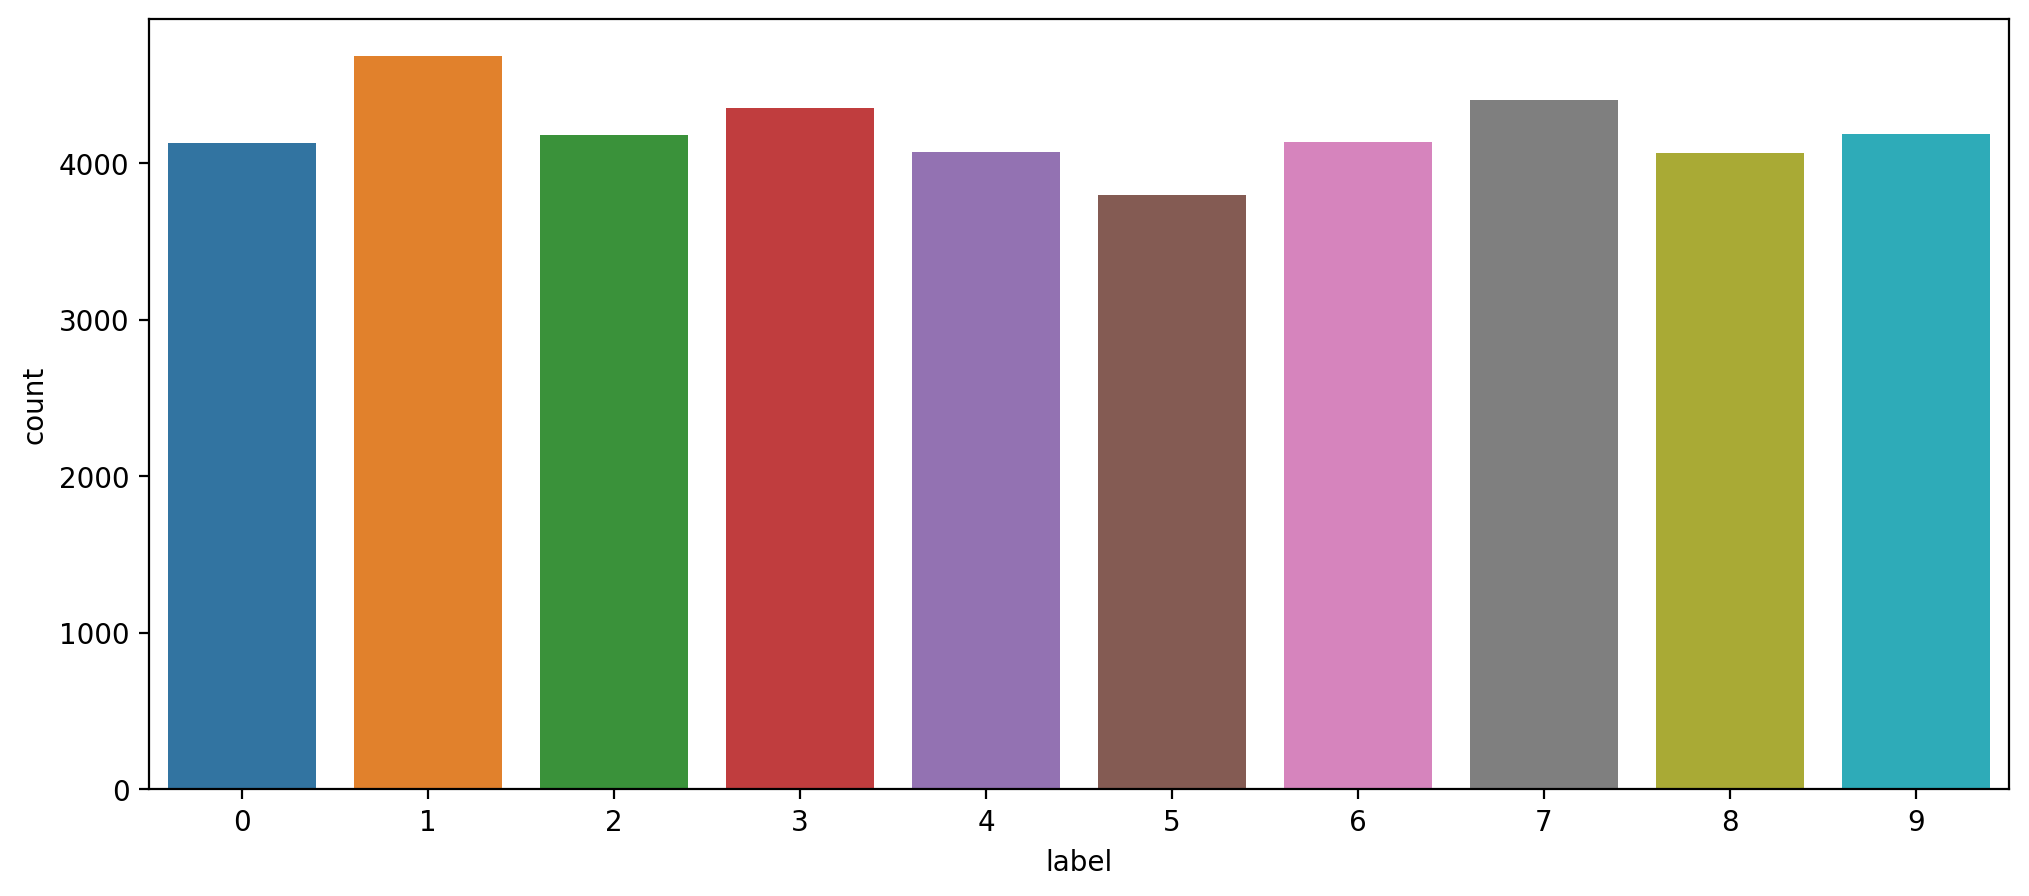

In [7]:
plt.figure(figsize = (12,5), dpi = 200)
sns.countplot('label', data = data)

In [8]:
X = data.drop(['label'], axis = 1).values
Y = data[['label']].values

print('Data Shape   : ', X.shape)
print('Labels Shape : ', Y.shape)

Data Shape   :  (42000, 784)
Labels Shape :  (42000, 1)


(-0.5, 27.5, 27.5, -0.5)

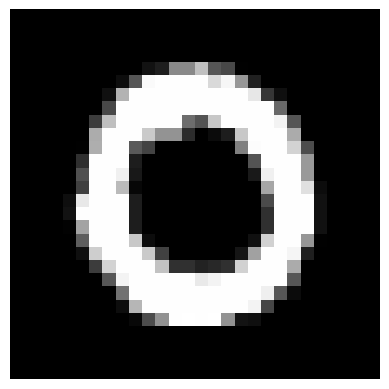

In [9]:
plt.imshow(X[1].reshape(28,28), cmap = 'gray')
plt.axis('off')

In [10]:
np.set_printoptions(linewidth = 300)
print(X[1].reshape(28,28))

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18  30 137 137 192  86  72   1   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  13  86 250 254 254 254 254 217 246 151  32   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  16 179 254 254 254 254 254 254 254 254 254 231  54  15   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  72 254 254 254 254 254 254 254 254 254 254 254 254 104   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  61 191 254 254 254 254 254 109  83 199 254 254 254 25

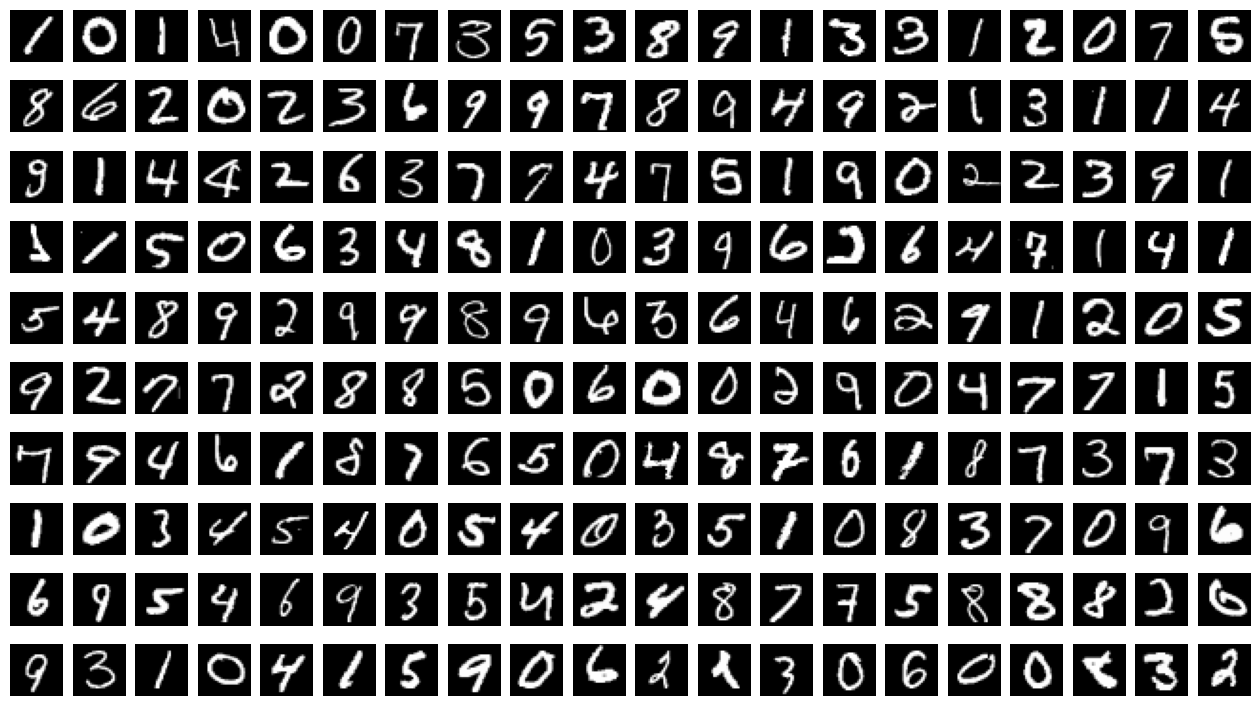

In [11]:
plt.figure(figsize = (16,9))
for i in range(200):
    plt.subplot(10,20, i+1)
    plt.imshow(X[i].reshape(28,28), cmap = 'gray')
    plt.axis('off')

In [12]:
X = X/255

In [13]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3)

In [14]:
print('Training Data Shape   : ', x_train.shape)
print('Training Labels Shape : ', y_train.shape)
print('Testing Data Shape    : ', x_test.shape)
print('Testing Labels Shape  : ', y_test.shape)

Training Data Shape   :  (29400, 784)
Training Labels Shape :  (29400, 1)
Testing Data Shape    :  (12600, 784)
Testing Labels Shape  :  (12600, 1)


---
# Decision Tree Classifier
DecisionTreeClassifier(
>      class_weight=None, criterion='entropy', max_depth=8
       max_features=None, max_leaf_nodes=None,
       min_impurity_decrease=0.0, min_impurity_split=None,
       min_samples_leaf=1, min_samples_split=2,
       min_weight_fraction_leaf=0.0, presort=False,
       random_state=14, splitter='best')

In [15]:
# Not an Ensemble
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(max_depth = 15)
classifier.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=15)

In [16]:
pred_train = classifier.predict(x_train)
pred_test  = classifier.predict(x_test)

print('Training Set Accuracy : ', accuracy_score(y_train, pred_train))
print('Testing Set Accuracy  : ', accuracy_score(y_test, pred_test))

Training Set Accuracy :  0.9846938775510204
Testing Set Accuracy  :  0.8522222222222222


---
# Random Forest Classifier
RandomForestClassifier(
>     bootstrap=True, class_weight=None, criterion='entropy',
      max_depth=10, max_features='auto', max_leaf_nodes=None,
      min_impurity_decrease=0.0, min_impurity_split=None,
      min_samples_leaf=1, min_samples_split=2,
      min_weight_fraction_leaf=0.0, n_estimators=10,
      n_jobs=None, oob_score=False, random_state=14,verbose=0,
      warm_start=False)

In [17]:
# Bagging Ensemble
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 200, max_depth = 10)
classifier.fit(x_train,y_train)

RandomForestClassifier(max_depth=10, n_estimators=200)

In [18]:
pred_train = classifier.predict(x_train)
pred_test  = classifier.predict(x_test)

print('Training Set Accuracy : ', accuracy_score(y_train, pred_train))
print('Testing Set Accuracy  : ', accuracy_score(y_test, pred_test))

Training Set Accuracy :  0.9756802721088436
Testing Set Accuracy  :  0.9427777777777778


---
# XGBoost
>   base_score=0.5, booster='gbtree', colsample_bylevel=1,
    colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
    importance_type='gain', interaction_constraints='',
    learning_rate=0.300000012, max_delta_step=0, max_depth=6,
    min_child_weight=1, missing=nan, monotone_constraints='()',
    n_estimators=5, n_jobs=4, num_parallel_tree=1,
    objective='multi:softprob', random_state=0, reg_alpha=0,
    reg_lambda=1, scale_pos_weight=None, subsample=1,
    tree_method='exact', use_label_encoder=True,
    validate_parameters=1, verbosity=None)

In [19]:
# Boosting ensemble
from xgboost import XGBClassifier
classifier = XGBClassifier(n_estimators = 50, max_depth = 5)
classifier.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=50, n_jobs=None, num_parallel_tree=None,
              objective='multi:softprob', predictor=None, ...)

In [20]:
pred_train = classifier.predict(x_train)
pred_test  = classifier.predict(x_test)

print('Training Set Accuracy : ', accuracy_score(y_train, pred_train))
print('Testing Set Accuracy  : ', accuracy_score(y_test, pred_test))

Training Set Accuracy :  0.999421768707483
Testing Set Accuracy  :  0.9642063492063492


---
# Light GBM
LGBMClassifier(
>  boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
   importance_type='split', learning_rate=0.1, max_depth=-1,
   min_child_samples=20, min_child_weight=0.001,min_split_gain=0.0,
   n_estimators=5, n_jobs=-1, num_leaves=31, objective=None,
   random_state=None, reg_alpha=0.0, reg_lambda=0.0, silent=True,
   subsample=1.0, subsample_for_bin=200000, subsample_freq=0)

In [21]:
# Boosting Ensemble
from lightgbm import LGBMClassifier
classifier = LGBMClassifier(n_estimators = 50)
classifier.fit(x_train, y_train)

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.076601 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 101059
[LightGBM] [Info] Number of data points in the train set: 29400, number of used features: 611
[LightGBM] [Info] Start training from score -2.311125
[LightGBM] [Info] Start training from score -2.174725
[LightGBM] [Info] Start training from score -2.315595
[LightGBM] [Info] Start training from score -2.277395
[LightGBM] [Info] Start training from score -2.334729
[LightGBM] [Info] Start training from score -2.400791
[LightGBM] [Info] Start training from score -2.311468
[LightGBM] [Info] Start training from score -2.268479
[LightGBM] [Info] Start training from score -2.336839
[LightGBM] [Info] Start training from score -2.310096


LGBMClassifier(n_estimators=50)

In [22]:
pred_train = classifier.predict(x_train)
pred_test  = classifier.predict(x_test)

print('Training Set Accuracy : ', accuracy_score(y_train, pred_train))
print('Testing Set Accuracy  : ', accuracy_score(y_test, pred_test))

Training Set Accuracy :  0.9999659863945578
Testing Set Accuracy  :  0.9645238095238096


---
# Ada Boost
>   base_estimator=None, *, n_estimators=50, learning_rate=1.0, algorithm='SAMME.R',random_state=None)

In [23]:
estimator = DecisionTreeClassifier(max_depth = 8)

from sklearn.ensemble import AdaBoostClassifier
classifier = AdaBoostClassifier(estimator, n_estimators = 50)
classifier.fit(x_train, y_train)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=8))

In [24]:
pred_train = classifier.predict(x_train)
pred_test  = classifier.predict(x_test)

print('Training Set Accuracy : ', accuracy_score(y_train, pred_train))
print('Testing Set Accuracy  : ', accuracy_score(y_test, pred_test))

Training Set Accuracy :  0.9798299319727891
Testing Set Accuracy  :  0.9082539682539682


----
# ==============================================
# Stacking

In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [26]:
knn_classifier   = KNeighborsClassifier(n_neighbors = 6)
dt_classifier    = DecisionTreeClassifier(max_depth = 12)
rf_classifier    = RandomForestClassifier(n_estimators = 100, max_depth = 10)
xgb_classifier   = XGBClassifier(n_estimators = 50, max_depth = 5)
lgbm_classifier  = LGBMClassifier(n_estimators = 50)

In [27]:
from sklearn.ensemble import VotingClassifier
classifier = VotingClassifier(estimators = [('knn', knn_classifier),
                                            ('dt', dt_classifier),
                                            ('rf', rf_classifier),
                                            ('xgb', xgb_classifier),
                                            ('lgbm', lgbm_classifier)], voting = 'hard')

classifier.fit(x_train, y_train)

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.091337 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 101059
[LightGBM] [Info] Number of data points in the train set: 29400, number of used features: 611
[LightGBM] [Info] Start training from score -2.311125
[LightGBM] [Info] Start training from score -2.174725
[LightGBM] [Info] Start training from score -2.315595
[LightGBM] [Info] Start training from score -2.277395
[LightGBM] [Info] Start training from score -2.334729
[LightGBM] [Info] Start training from score -2.400791
[LightGBM] [Info] Start training from score -2.311468
[LightGBM] [Info] Start training from score -2.268479
[LightGBM] [Info] Start training from score -2.336839
[LightGBM] [Info] Start training from score -2.310096


VotingClassifier(estimators=[('knn', KNeighborsClassifier(n_neighbors=6)),
                             ('dt', DecisionTreeClassifier(max_depth=12)),
                             ('rf', RandomForestClassifier(max_depth=10)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_...
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, ma

In [28]:

pred_train = classifier.predict(x_train)
pred_test  = classifier.predict(x_test)

print('Training Set Accuracy : ', accuracy_score(y_train, pred_train))
print('Testing Set Accuracy  : ', accuracy_score(y_test, pred_test))

Training Set Accuracy :  0.9964285714285714
Testing Set Accuracy  :  0.9661111111111111
